# Notebook for evaluating different merging methods

In [1]:
import numpy as np
import pickle

from COSIE.data_preprocessing import load_data
from COSIE.utils import setup_seed
from COSIE.configure import get_default_config
from COSIE.COSIE_framework import COSIE_model
from COSIE.downstream_analysis import *

import os
import matplotlib.pyplot as plt
from COSIE.downstream_analysis import plot_histology_clusters  # reuse as-is


import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.sparse import issparse
from sklearn.preprocessing import MinMaxScaler
from anndata import AnnData
from scipy.stats import rankdata
from matplotlib import patches
from pathlib import Path 


from scipy.spatial import cKDTree

config = get_default_config()
setup_seed(config['training']['seed'])

In [2]:
COSIE_OUTPUT_480PANEL_DIR = "./cosie_output_480panelonly"

COSIE_OUTPUT_5KPANEL_DIR = "./cosie_output_5kpanelonly"

In [ ]:


# ═══════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════


def create_normalized_adata(adata):
    dense_X = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
    scaler = MinMaxScaler()
    normalized_X = scaler.fit_transform(dense_X)
    return AnnData(X=normalized_X, obs=adata.obs.copy(),
                   var=adata.var.copy(), obsm=adata.obsm.copy())



def get_gene_stats_per_sample(adata_list, panel_label):
    """
    Returns a dict of DataFrames: {'mean': df, 'pct_nz': df, 'cv': df}
    Each DataFrame: rows=genes, cols=samples
    """
    n_samples = len(adata_list)
    genes     = adata_list[0].var_names

    mean_mat  = np.zeros((len(genes), n_samples))
    pct_nz_mat = np.zeros((len(genes), n_samples))
    cv_mat    = np.zeros((len(genes), n_samples))

    for i, adata in enumerate(adata_list):
        X = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
        mean_mat[:, i]   = X.mean(axis=0)
        pct_nz_mat[:, i] = (X > 0).mean(axis=0) * 100
        std                = X.std(axis=0)
        cv_mat[:, i]     = std / (mean_mat[:, i] + 1e-9)

    sample_cols = [f'S{i+1}' for i in range(n_samples)]
    return {
        'mean':   pd.DataFrame(mean_mat,   index=genes, columns=sample_cols),
        'pct_nz': pd.DataFrame(pct_nz_mat, index=genes, columns=sample_cols),
        'cv':     pd.DataFrame(cv_mat,     index=genes, columns=sample_cols),
    }

def get_expr(adata, gene):
    idx = list(adata.var_names).index(gene)
    X   = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
    return X[:, idx]

def rank_norm(x):
    """Rank-normalize to [0, 1] — compares spatial pattern, not level."""
    r = rankdata(x, method='average')
    return (r - 1) / (len(r) - 1)

def get_xy(adata):
    return adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1]



"""Compute per-gene stats for a single AnnData sample."""

def get_per_gene_stats_single(adata, label):
    
    X = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
    mean = np.mean(X, axis=0)
    return pd.DataFrame({
        f'{label}_mean':     mean,
        f'{label}_var':      np.var(X, axis=0),
        f'{label}_cv':       np.std(X, axis=0) / (mean + 1e-9),
        f'{label}_median':   np.median(X, axis=0),
        f'{label}_pct_zero': np.mean(X == 0, axis=0),
    }, index=adata.var_names)


from matplotlib.patches import Patch
import matplotlib.lines as mlines

def compute_gene_agreement(stats_480, stats_5k, metric='mean'):
    """
    For each gene, compute Pearson r and Spearman rho
    of its per-sample `metric` vector between the two panels.
    Also compute mean difference and log2 fold change.
    """
    df_480 = stats_480[metric]   # genes × samples
    df_5k  = stats_5k[metric]

    records = []
    for gene in df_480.index:
        v_480 = df_480.loc[gene].values   # length 6
        v_5k  = df_5k.loc[gene].values

        # Pearson / Spearman across 6 samples
        if np.std(v_480) > 0 and np.std(v_5k) > 0:
            r,   p_r   = pearsonr(v_480,  v_5k)
            rho, p_rho = spearmanr(v_480, v_5k)
        else:
            r = rho = p_r = p_rho = np.nan

        mean_480 = v_480.mean()
        mean_5k  = v_5k.mean()

        # Mean absolute difference (normalised scale since both MinMax)
        mean_diff = mean_5k - mean_480
        abs_diff  = abs(mean_diff)

        # Log2 fold change of means
        log2fc = np.log2((mean_5k + 1e-6) / (mean_480 + 1e-6))

        records.append({
            'gene':        gene,
            'pearson_r':   r,
            'pearson_p':   p_r,
            'spearman_rho': rho,
            'mean_480':    mean_480,
            'mean_5k':     mean_5k,
            'mean_diff':   mean_diff,   # + means 5k higher
            'abs_diff':    abs_diff,
            'log2fc':      log2fc,      # + means 5k higher
        })

    df = pd.DataFrame(records).set_index('gene')
    return df




def gene_mean_expr(adata, genes):
    sub = adata[:, genes]
    X = sub.X.toarray() if hasattr(sub.X, 'toarray') else sub.X
    return X.mean(axis=0)




In [ ]:

def assign_he_features_to_cells(adata_he_superpixel, xenium_spatial):
    """
    For each Xenium cell location, find nearest HE superpixel and grab its feature vector.
    Returns a new AnnData aligned 1:1 with the Xenium cells.
    """
    superpixel_coords = adata_he_superpixel.obsm['spatial']
    superpixel_features = adata_he_superpixel.X
    if not isinstance(superpixel_features, np.ndarray):
        superpixel_features = superpixel_features.toarray()

    tree = cKDTree(superpixel_coords)
    distances, nearest_idx = tree.query(xenium_spatial, k=1)

    matched_features = superpixel_features[nearest_idx]

    adata_he_cell = ad.AnnData(X=matched_features.astype(np.float32))
    adata_he_cell.obsm['spatial'] = xenium_spatial.copy()

    # optional: keep track of match quality
    adata_he_cell.obs['nearest_superpixel_dist'] = distances

    return adata_he_cell

In [ ]:

SAVE_DIR = './hinge_evaluation_plots'  
os.makedirs(SAVE_DIR, exist_ok=True)   


# step 0: Load prediction, UNI embeddings

In [5]:

pairs = [('s1','s7'), ('s2','s8'), ('s3','s9'),
         ('s4','s10'), ('s5','s11'), ('s6','s12')]


In [6]:
with open("./cosie_prediction/480and5kseparate_panels/predicted_rna.pkl", "rb") as f:
    predicted_rna=pickle.load(f)

predicted_rna

{'s1': AnnData object with n_obs × n_vars = 6989 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's2': AnnData object with n_obs × n_vars = 8978 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's3': AnnData object with n_obs × n_vars = 449221 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's4': AnnData object with n_obs × n_vars = 7442 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's5': AnnData object with n_obs × n_vars = 16540 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's6': AnnData object with n_obs × n_vars = 24862 × 5101
     obs: 'nearest_superpixel_dist'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 's7': AnnData object wi

### subset the prediction to the interesecting genes

### UNI feature

In [8]:
CATCH_result_base_dir = Path("/home/yyamamo2/lupus_project/Xenium_skin_COSIE/CATCH-main/result_single")
transformation_matrix_base_dir = Path("/home/yyamamo2/lupus_project/Xenium_skin_COSIE/cosie-main/7_31_2026_skin_xenium_transformation")

panel_480_xenium_to_unifeature_dict = {

"s1": "64841_Region_002",
"s2":"64841_Region_003",
"s3":"64841_Region_001",
"s4":"104483_Region_003",
"s5":"104483_Region_002",
"s6":"104483_Region_001"


    
}


panel_480_xenium_to_transformation_dict = {

"s1": "480_15236-1-16A",
"s2":"480_15281-1-16A",
"s3":"480_HS44",
"s4":"480_15037-1-16A",
"s5":"480_15077-1-16A",
"s6":"480_HV2"



    
}

panel_5k_xenium_to_unifeature_dict = {

"s7": "64839_Region_002",
"s8":"64839_Region_003",
"s9":"64839_Region_001",
"s10":"81614_Region_001",
"s11":"81614_Region_002",
"s12":"81614_Region_003"


    
}
panel_5k_xenium_to_transformation_dict = {

"s7": "5k_15236-1-16A",
"s8":"5k_15281-1-16B",
"s9":"5k_HS44",
"s10":"5k_15037-1-16A",
"s11":"5k_15077-1-16A",
"s12":"5k_HV2"



    
}



### Loading 480


###############################################################################

Sample name: s1


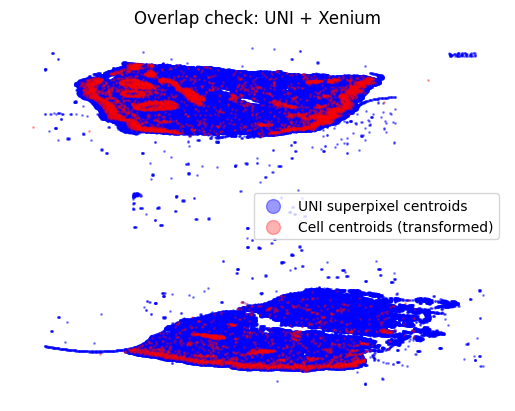


###############################################################################

Sample name: s2


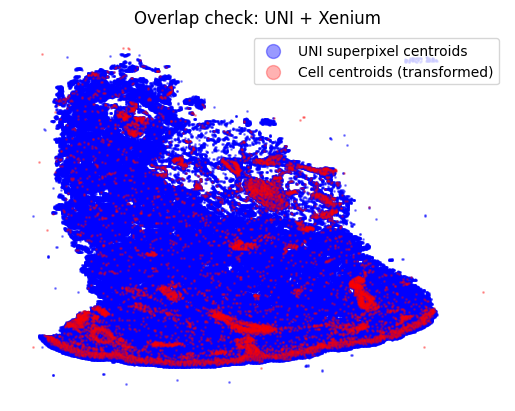


###############################################################################

Sample name: s3


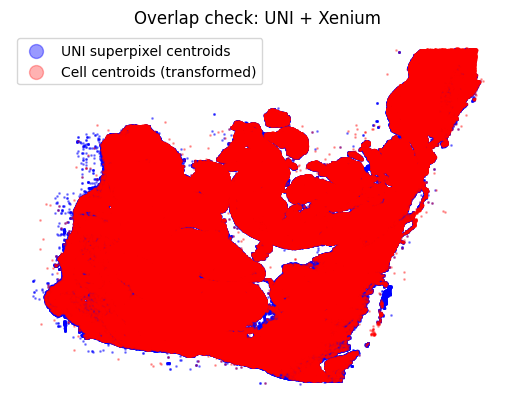


###############################################################################

Sample name: s4


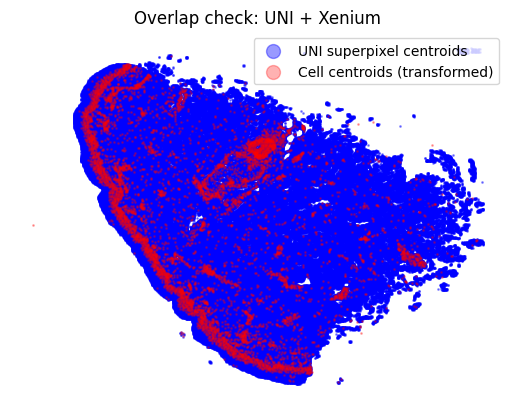


###############################################################################

Sample name: s5


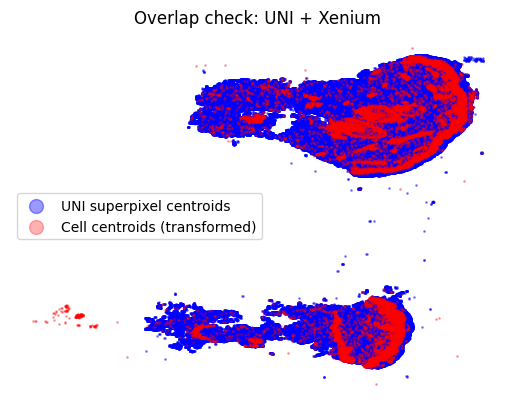


###############################################################################

Sample name: s6


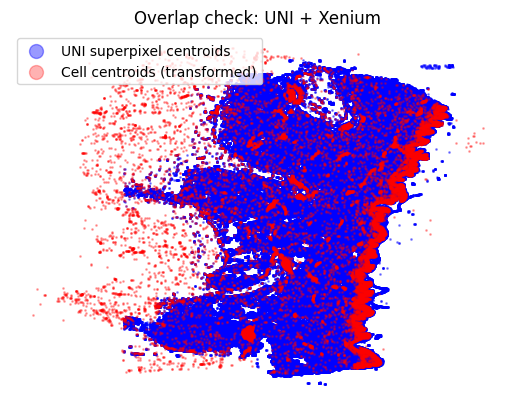

In [11]:
uni_480_list = []


for sample_name, uni_sample_name in panel_480_xenium_to_unifeature_dict.items():
    print()
    print("###############################################################################")
    print()
    print(f"Sample name: {sample_name}")

    

    ##########################################################################
    #Look at UNI feature

    adata_he = sc.read( CATCH_result_base_dir/"480_panel" / uni_sample_name / "480_panel"/uni_sample_name/ "super_pixel_emb.h5ad")


    

    scale_factor = 16
    # UNI superpixel centroids (from the h5ad you loaded)
    adata_he.obsm["spatial"][:, 0] = adata_he.obsm["spatial"][:, 0]* scale_factor
    adata_he.obsm["spatial"][:, 1] = adata_he.obsm["spatial"][:, 1]* scale_factor


    
    ##########################################################################

    
    
    # UNI superpixel centroids (from the h5ad you loaded)
    uni_x = adata_he.obsm["spatial"][:, 0]
    uni_y = adata_he.obsm["spatial"][:, 1]
    plt.scatter(uni_x, uni_y, s=3, c="blue", alpha=0.4, label="UNI superpixel centroids")
    
    # Xenium cell centroids, already transformed into H&E space
    pred_x = predicted_rna[sample_name].obsm["spatial"][:, 0]
    pred_y = predicted_rna[sample_name].obsm["spatial"][:, 1]
    
    
    plt.scatter(pred_x, pred_y, s=3, c="red", alpha=0.3, label="Cell centroids (transformed)")
    
    plt.legend(markerscale=10)
    plt.title("Overlap check: UNI + Xenium")
    plt.axis("off")
    plt.show()
    
    
    adata_he_cell = assign_he_features_to_cells(adata_he, predicted_rna[sample_name].obsm['spatial'])
    uni_480_list.append(adata_he_cell)
    
    




### Loading 5k


###############################################################################

Sample name: s7


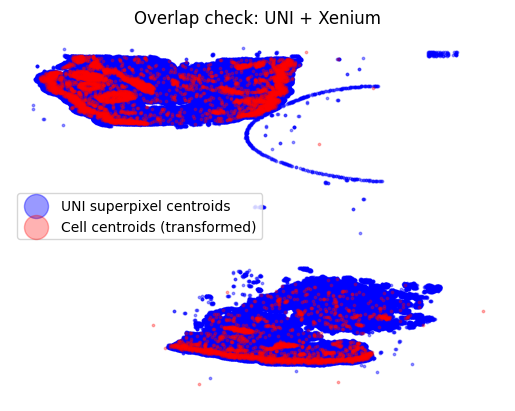


###############################################################################

Sample name: s8


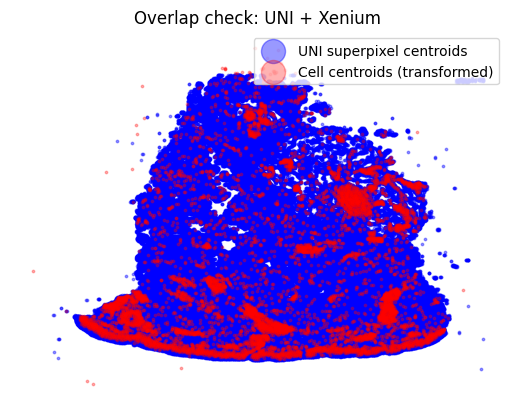


###############################################################################

Sample name: s9


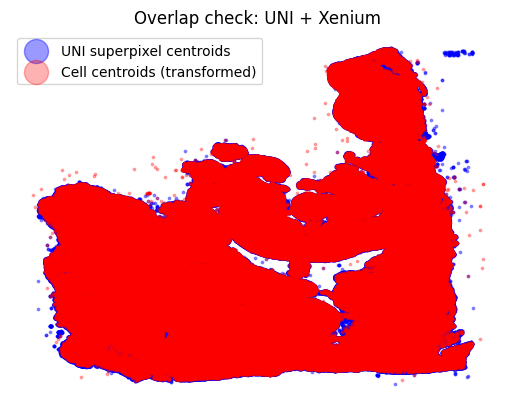


###############################################################################

Sample name: s10


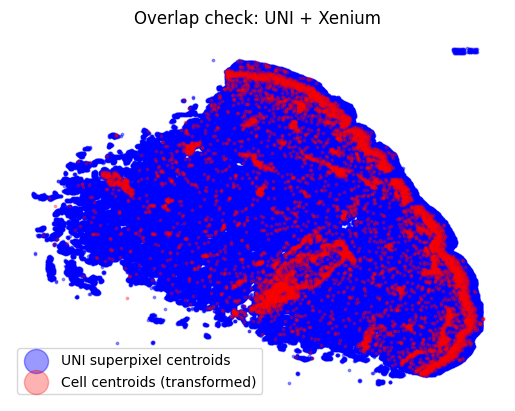


###############################################################################

Sample name: s11


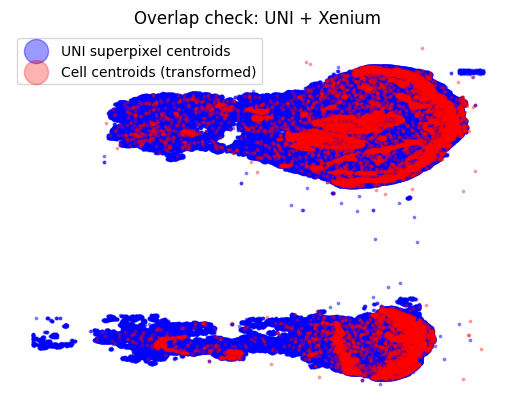


###############################################################################

Sample name: s12


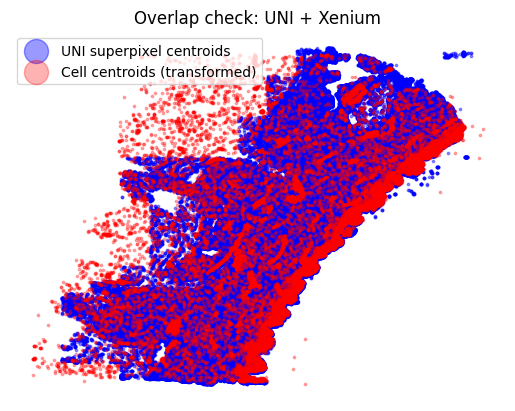

In [12]:
uni_5k_list = []


for sample_name, uni_sample_name in panel_5k_xenium_to_unifeature_dict.items():
    print()
    print("###############################################################################")
    print()
    print(f"Sample name: {sample_name}")

    

    ##########################################################################
    #Look at UNI feature

    adata_he = sc.read( CATCH_result_base_dir/"5k_panel" / uni_sample_name / "5k_panel"/uni_sample_name/ "super_pixel_emb.h5ad")


    

    scale_factor = 16
    # UNI superpixel centroids (from the h5ad you loaded)
    adata_he.obsm["spatial"][:, 0] = adata_he.obsm["spatial"][:, 0]* scale_factor
    adata_he.obsm["spatial"][:, 1] = adata_he.obsm["spatial"][:, 1]* scale_factor




    
    ##########################################################################

    
    
    # UNI superpixel centroids (from the h5ad you loaded)
    uni_x = adata_he.obsm["spatial"][:, 0]
    uni_y = adata_he.obsm["spatial"][:, 1]
    plt.scatter(uni_x, uni_y, s=3, c="blue", alpha=0.4, label="UNI superpixel centroids")
    
    # Xenium cell centroids, already transformed into H&E space
    pred_x = predicted_rna[sample_name].obsm["spatial"][:, 0]
    pred_y = predicted_rna[sample_name].obsm["spatial"][:, 1]
    
    
    plt.scatter(pred_x, pred_y, s=3, c="red", alpha=0.3, label="Cell centroids (transformed)")
    
    plt.legend(markerscale=10)
    plt.title("Overlap check: UNI + Xenium")
    plt.axis("off")
    plt.show()
    
    
    adata_he_cell = assign_he_features_to_cells(adata_he, predicted_rna[sample_name].obsm['spatial'])
    uni_5k_list.append(adata_he_cell)
    


# step 1: automatically align the data. Skip this step if they are aligned in another way

### Align cells using both coarse and fine alignment

In [ ]:
from hinge.automatic_alignment import *

PRE_ALIGNED   = False   # <- set True if externally pre-registered


ICP_TRIM_FRAC = 0.85
ICP_N_ITER    = 100
ICP_TOL       = 1e-7

In [ ]:



registration_results = {}

for name_480, name_5k in pairs:
    print(f"\n{'='*58}")
    print(f"  Aligning  {name_5k}  ->  {name_480}")
    print(f"{'='*58}")

    xy_480 = predicted_rna[name_480].obsm['spatial']
    xy_5k  = predicted_rna[name_5k].obsm['spatial']

    xy_5k_registered, A = align_section_pair(
        xy_480, xy_5k,
        pre_aligned=PRE_ALIGNED,
        trim_frac=ICP_TRIM_FRAC,
        n_iter=ICP_N_ITER,
        tol=ICP_TOL,
        pair_label=f"{name_480}/{name_5k}"
    )

    registration_results[(name_480, name_5k)] = {
        'xy_5k_registered': xy_5k_registered,
        'A': A,
    }

update_coordinates(registration_results, pairs, uni_5k_list, predicted_rna)
plot_alignment_results(pairs, predicted_rna, registration_results, SAVE_DIR)

# Step 2 Merge cells

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(*s1_xy.T, s=1, alpha=0.4, label='s1 (5k)')
ax.scatter(*s7_xy_registered.T, s=1, alpha=0.4, label='s7 registered')
ax.legend(); ax.set_aspect('equal')

In [ ]:

tree = cKDTree(s7_xy_registered)
all_dist, _ = tree.query(s1_xy, k=1)

plt.hist(all_dist, bins=100, range=(0, 200))
#plt.axvline(15, color='r', linestyle='--', label='current cutoff (15)')
plt.xlabel('nearest neighbor distance'); plt.legend()
plt.show()

print(np.percentile(all_dist, [25, 50, 75, 90]))

In [ ]:
"""
Trying greedy one to one matching algorithm

1. find nearest neighbors, euclidian distance
2. sort by least distance to most
3. match the best pair
4. remember the pair
5. match the best remaining pair
6. Continues until the best remaining pair is above max distance

"""

def match_cells_greedy_unique(xy_480, xy_5k_registered, max_dist=35.0):
    tree = cKDTree(xy_5k_registered)
    dist, idx = tree.query(xy_480, k=1)

    order = np.argsort(dist)
    used_480 = np.zeros(len(xy_480), dtype=bool)
    used_5k = np.zeros(len(xy_5k_registered), dtype=bool)

    matched_480, matched_5k = [], []
    for i in order:
        if dist[i] > max_dist:
            break  # sorted ascending, so all remaining are worse
        j = idx[i]
        if used_480[i] or used_5k[j]:
            continue
        used_480[i] = used_5k[j] = True
        matched_480.append(i)
        matched_5k.append(j)

    matched_480 = np.array(matched_480)
    matched_5k = np.array(matched_5k)
    print(f"matched {len(matched_480)}/{len(xy_480)} cells "
          f"({len(matched_480)/len(xy_480):.1%}), "
          f"median dist={np.median(dist[matched_480]):.2f}, "
          f"duplicates={len(matched_5k)-len(np.unique(matched_5k))}")
    return matched_480, matched_5k



idx480_greedy, idx5k_greedy = match_cells_greedy_unique( s7_xy_registered,s1_xy, max_dist=35)

### Applying this to all samples

In [ ]:
'''
A wrapper function that does
1. coarse + icp align
2. greedy matching
'''

def register_and_match(xy_480, xy_5k, max_dist=35.0, verbose_label=""):
    xy_5k_coarse = coarse_align(xy_5k, xy_480)
    xy_5k_registered, A = icp_affine_robust(xy_5k_coarse, xy_480, trim_frac=0.7)
    idx480, idx5k = match_cells_greedy_unique(xy_480, xy_5k_registered, max_dist=max_dist)
    if verbose_label:
        print(f"[{verbose_label}] done.\n")
    return idx480, idx5k, xy_5k_registered


In [ ]:
'''
Merges two panels from matching cells to one panel
Combines 480 gene prediction with genes exclusively in 5k gene prediction
For genes overlapping between 480 and 5k, 480 prediction takes priority

'''


def merge_pair(pred_5k_obj, pred_480_obj, idx_5101, idx_480, sample_name):
    """
    pred_5k_obj: e.g. predicted_rna['s1'] — 5101-var predicted panel (480-origin sample)
    pred_480_obj:  e.g. predicted_rna['s7'] — 480-var predicted panel (5k-origin sample)
    idx_5101, idx_480: matched, aligned index arrays from your greedy/MNN matching
    """
    a5101 = pred_5k_obj[idx_5101].copy()
    a480  = pred_480_obj[idx_480].copy()

    new_ids = [f"{sample_name}_c{i}" for i in range(a5101.n_obs)]
    a5101.obs_names = new_ids
    a480.obs_names  = new_ids

    exclusive_5101_genes = sorted(set(a5101.var_names) - set(a480.var_names))

    X_480      = sp.csr_matrix(a480.X) if not sp.issparse(a480.X) else a480.X
    X_5101_excl = a5101[:, exclusive_5101_genes].X
    X_5101_excl = sp.csr_matrix(X_5101_excl) if not sp.issparse(X_5101_excl) else X_5101_excl

    X_comb = sp.hstack([X_480, X_5101_excl]).tocsr()

    var = pd.DataFrame(index=list(a480.var_names) + exclusive_5101_genes)
    var['source'] = (['480_panel_prediction'] * a480.n_vars +
                      ['5k_panel_prediction_only'] * len(exclusive_5101_genes))

    merged = ad.AnnData(X=X_comb, obs=a480.obs.copy(), var=var,
                         obsm={'spatial': a480.obsm['spatial']})
    merged.obs['sample'] = sample_name
    return merged

In [ ]:

match_results = {}
for name5k, name480 in pairs:
    xy_480 = predicted_rna[name480].obsm['spatial']
    xy_5k  = predicted_rna[name5k].obsm['spatial']
    idx480, idx5k, xy_5k_reg = register_and_match(xy_480, xy_5k, max_dist=50.0, verbose_label=name5k)
    match_results[name5k] = dict(idx480=idx480, idx5k=idx5k, xy_5k_registered=xy_5k_reg)

#### Checking the alignment result. Most of them looks good, except s6-s12. I don't think this pair's alignment is very good, evidently by the low matching % as well

In [ ]:
def plot_all_pairs_alignment(pairs, predicted_rna, match_results):
    n = len(pairs)
    fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))

    for row, (name5k, name480) in enumerate(pairs):
        xy_target     = predicted_rna[name480].obsm['spatial']       # anchor, never moves
        xy_source_raw = predicted_rna[name5k].obsm['spatial']        # source, before registration
        xy_source_reg = match_results[name5k]['xy_5k_registered']    # source, after registration

        ax0, ax1 = axes[row]

        ax0.scatter(*xy_target.T, s=1, alpha=0.4, label=f'{name480} (target)')
        ax0.scatter(*xy_source_raw.T, s=1, alpha=0.4, label=f'{name5k} (raw)')
        ax0.set_title(f'{name5k}/{name480} — before'); ax0.set_aspect('equal'); ax0.legend(fontsize=7)

        ax1.scatter(*xy_target.T, s=1, alpha=0.4, label=f'{name480} (target)')
        ax1.scatter(*xy_source_reg.T, s=1, alpha=0.4, label=f'{name5k} (registered)')
        ax1.set_title(f'{name5k}/{name480} — after'); ax1.set_aspect('equal'); ax1.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

plot_all_pairs_alignment(pairs, predicted_rna, match_results)

In [ ]:
merged_list = []
for name5k, name480 in pairs:
    res = match_results[name5k]
    merged = merge_pair(predicted_rna[name5k], predicted_rna[name480],
                         res['idx5k'], res['idx480'], sample_name=name5k)
    merged_list.append(merged)

combined = ad.concat(merged_list, join='outer', label='sample_batch', index_unique='-')
print(combined)

In [ ]:
merged_list

In [ ]:
combined

In [ ]:
combined.obs

# Step 4: evaluation, View variance in overlapping genes

In [ ]:


def compare_overlap_predictions(pred_5k_obj, pred_480_obj, idx_5k, idx_480, sample_name):
    overlap_genes = sorted(set(pred_5k_obj.var_names) & set(pred_480_obj.var_names))

    a5k  = pred_5k_obj[idx_5k, overlap_genes]
    a480 = pred_480_obj[idx_480, overlap_genes]

    X5k  = a5k.X.toarray()  if hasattr(a5k.X, 'toarray')  else a5k.X
    X480 = a480.X.toarray() if hasattr(a480.X, 'toarray') else a480.X

    # per-gene correlation across matched cells
    gene_corr = {}
    for i, g in enumerate(overlap_genes):
        if X5k[:, i].std() > 0 and X480[:, i].std() > 0:
            gene_corr[g] = np.corrcoef(X5k[:, i], X480[:, i])[0, 1]
        else:
            gene_corr[g] = np.nan

    corr_df = pd.Series(gene_corr, name='pearson_r').sort_values()

    # per-cell, per-gene absolute + relative difference
    abs_diff = np.abs(X5k - X480)
    mean_expr = (X5k + X480) / 2
    rel_diff = np.divide(abs_diff, mean_expr, out=np.zeros_like(abs_diff), where=mean_expr > 0)

    print(f"[{sample_name}] {len(overlap_genes)} overlapping genes, {X5k.shape[0]} matched cells")
    print(f"  median gene-level correlation: {corr_df.median():.3f}")
    print(f"  mean abs diff: {abs_diff.mean():.3f}, mean rel diff: {rel_diff.mean():.3f}")

    return corr_df, abs_diff, rel_diff, overlap_genes

results = {}
for name5k, name480 in pairs:
    res = match_results[name5k]
    results[name5k] = compare_overlap_predictions(
        predicted_rna[name5k], predicted_rna[name480],
        res['idx5k'], res['idx480'], sample_name=name5k
    )

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(12,4))
for name5k, _ in pairs:
    corr_df, *_ = results[name5k]
    axes[0].hist(corr_df.dropna(), bins=30, alpha=0.5, label=name5k)
axes[0].set_xlabel('per-gene Pearson r (480-pred vs 5k-pred)'); axes[0].legend(fontsize=7)

# genes that disagree most, pooled across samples, in one sample as an example
corr_df, *_ = results['s1']
corr_df.head(15).plot(kind='barh', ax=axes[1])
axes[1].set_title('lowest-agreement genes (s1 example)')
plt.tight_layout()